In [3]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df_features = pd.read_csv("../data/processed/vn30_features.csv", 
                          index_col = "time", parse_dates = True)

print("Features dataset shape:", df_features.shape)



Features dataset shape: (2790, 7)


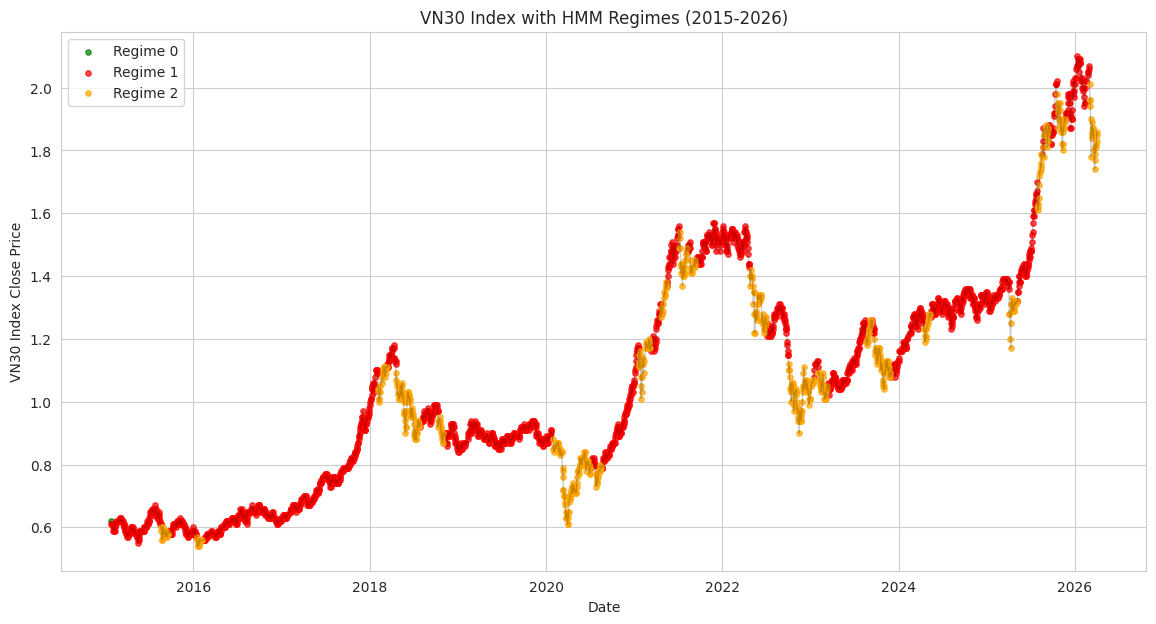

,log_return,volatility
regime,,
0,0.016261,0.008725
1,0.001038,0.009616
2,-0.001691,0.019752


In [ ]:
X = df_features[["log_return", "volatility"]].values

# Fit the HMM model
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X)

# Predict regime
df_features["regime"] = hmm_model.predict(X)

# Visualize the regimes
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
colors = ["green","red","orange"]

for i in range(hmm_model.n_components):
    regime_data = df_features[df_features['regime'] == i]
    plt.scatter(regime_data.index, regime_data["close"],
                c = colors[i], label=f'Regime {i}', s=15, alpha=0.7)
    
plt.plot(df_features.index, df_features['close'], color='black', alpha=0.2, linewidth=1)

plt.title("VN30 Index with HMM Regimes (2015-2026)")
plt.xlabel("Date")
plt.ylabel("VN30 Index Close Price")
plt.legend()
plt.show()

display(df_features.groupby("regime")[["log_return", "volatility"]].mean())


In [5]:
import vectorbt as vbt

df_features["signal"] = df_features["regime"].shift(1)

# Define entry and exit signals
#Long
entries = df_features["signal"] == 1
exits = df_features["signal"] != 1

#Short
short_entries = df_features["signal"] == 2
short_exits = df_features["signal"] != 2

#Backtest
#Assuming Captital:100,000,000 VND
#Comission: 0.15$ per trade

pf = vbt.Portfolio.from_signals(
    close= df_features["close"],
    entries=entries,
    exits = exits,
    short_entries=short_entries,
    short_exits=short_exits,
    init_cash= 100_000_000,
    fees = 0.0015,
    freq= "D"
)

display(pf.stats())

fig = pf.plot()
fig.show()


Start                         2015-01-23 07:00:00
End                           2026-04-02 07:00:00
Period                         2790 days 00:00:00
Start Value                           100000000.0
End Value                        226464750.508708
Total Return [%]                       126.464751
Benchmark Return [%]                   198.387097
Max Gross Exposure [%]                      100.0
Total Fees Paid                   24635138.869514
Max Drawdown [%]                        32.276924
Max Drawdown Duration           990 days 00:00:00
Total Trades                                   44
Total Closed Trades                            43
Total Open Trades                               1
Open Trade PnL                    11712713.135006
Win Rate [%]                            37.209302
Best Trade [%]                          79.936607
Worst Trade [%]                           -12.282
Avg Winning Trade [%]                   15.206616
Avg Losing Trade [%]                    -4.696238


#Proba

In [ ]:
df_features['SMA_50'] = df_features['close'].rolling(window=50).mean()
trend_signal = (df_features['close'] > df_features['SMA_50']).shift(1).fillna(False)


hmm_probs = pd.Series(probs[:, 1], index=df_features.index).shift(1).fillna(0)

def multi_factor_logic(row):
    prob = row['hmm_prob']
    uptrend = row['trend']
    
    if prob > 0.50 and uptrend:
        return 1.0
    else:
        return 0.0

signal_df = pd.DataFrame({'hmm_prob': hmm_probs, 'trend': trend_signal})

target_weights_multi = signal_df.apply(multi_factor_logic, axis=1)


/tmp/ipykernel_1868/1485083309.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trend_signal = (df_features['close'] > df_features['SMA_50']).shift(1).fillna(False)


In [ ]:
pf_prob = vbt.Portfolio.from_orders(
    close=df_features['close'],
    size=target_weights_multi,
    size_type='targetpercent',
    init_cash=100_000_000,
    fees=0.0015, 
    freq='D'
)
display(pf_prob.stats())

fig = pf_prob.plot()
fig.show()


Start                                2015-01-23 07:00:00
End                                  2026-04-02 07:00:00
Period                                2790 days 00:00:00
Start Value                                  100000000.0
End Value                               160374739.218539
Total Return [%]                               60.374739
Benchmark Return [%]                          198.387097
Max Gross Exposure [%]                             100.0
Total Fees Paid                          37260062.102337
Max Drawdown [%]                               29.567598
Max Drawdown Duration                 1183 days 00:00:00
Total Trades                                         110
Total Closed Trades                                  110
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   35.454545
Best Trade [%]                                 37.914198
Worst Trade [%]                